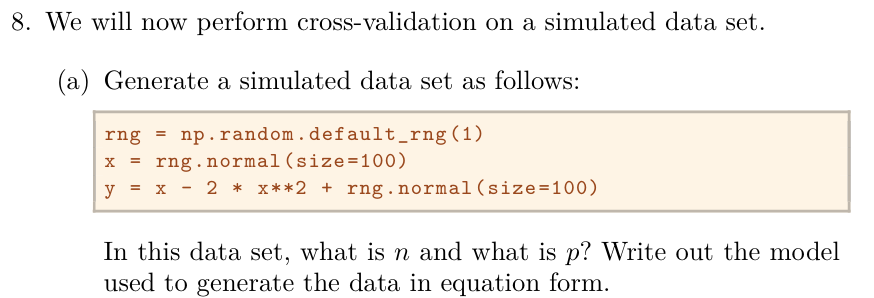

- n = 100 → number of observations (sample size)

- p = 1 → number of predictors (only one variable x)

- model: $y_i​=xi​−2xi^2​+ε_i​$

 (b) Create a scatterplot of X against Y . Comment on what you find

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

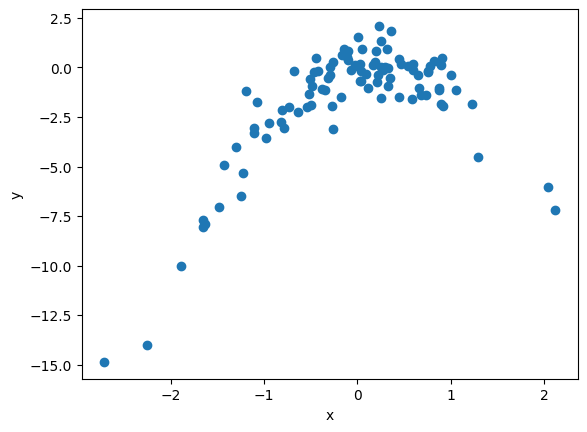

In [ ]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x-2*x**2+rng.normal(size=100)
plt.plot(x,y,'o')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

inverted U-shaped (quadratic) pattern

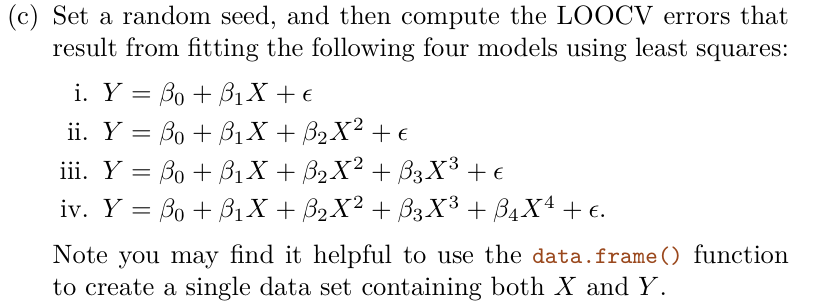

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# (1) Generate data
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

# (2) Put into a DataFrame (optional, for convenience)
data = pd.DataFrame({'X': x, 'Y': y})

# (3) Initialize LOOCV
loo = LeaveOneOut()

# (4) Function to compute LOOCV error for a given polynomial degree
def loocv_error(degree):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(x.reshape(-1, 1))
    errors = []

    for train_idx, test_idx in loo.split(X_poly):
        X_train, X_test = X_poly[train_idx], X_poly[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        model = LinearRegression().fit(X_train, y_train)
        y_pred = model.predict(X_test)
        errors.append((y_test - y_pred) ** 2)

    return np.mean(errors)

# (5) Compute LOOCV errors for models of degree 1–4
for d in range(1, 5):
    err = loocv_error(d)
    print(f"Degree {d} LOOCV error: {err:.4f}")

Degree 1 LOOCV error: 6.6330
Degree 2 LOOCV error: 1.1229
Degree 3 LOOCV error: 1.3018
Degree 4 LOOCV error: 1.3324


degree-2 polynomial has the lowest prediction error


LOOCV = Leave-One-Out Cross Validation
做法是：

1. 有 100 筆資料 → 一次拿出 1 筆當「測試資料」；剩下 99 筆當「訓練資料」。

2. 用訓練資料去 fit 模型，再用那 1 筆測試資料算誤差。

3. 重複 100 次（因為每筆資料都要當一次測試集）。

4. 把 100 次的誤差取平均 → 就是 LOOCV 誤差。

這個數字代表模型的「泛化能力」：越小越好。

(d) Repeat (c) using another random seed, and report your results.
 Are your results the same as what you got in (c)? Why?

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# (1) Generate data
rng = np.random.default_rng(12345)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

# (2) Put into a DataFrame (optional, for convenience)
data = pd.DataFrame({'X': x, 'Y': y})

# (3) Initialize LOOCV
loo = LeaveOneOut()

# (4) Function to compute LOOCV error for a given polynomial degree
def loocv_error(degree):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(x.reshape(-1, 1))
    errors = []

    for train_idx, test_idx in loo.split(X_poly):
        X_train, X_test = X_poly[train_idx], X_poly[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        model = LinearRegression().fit(X_train, y_train)
        y_pred = model.predict(X_test)
        errors.append((y_test - y_pred) ** 2)

    return np.mean(errors)

# (5) Compute LOOCV errors for models of degree 1–4
for d in range(1, 5):
    err = loocv_error(d)
    print(f"Degree {d} LOOCV error: {err:.4f}")

Degree 1 LOOCV error: 7.1302
Degree 2 LOOCV error: 1.0281
Degree 3 LOOCV error: 1.1237
Degree 4 LOOCV error: 1.2894


- The degree two model still has the lowest LOOCV error.

- The exact numerical values differ slightly because the data include random noise generated by a different seed.

 (e) Which of the models in (c) had the smallest LOOCV error? Is
 this what you expected? Explain your answer.

The second model
$
Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \varepsilon
$
had the smallest LOOCV error.

This result is expected, because the data were generated from
$
y = x - 2x^2 + \varepsilon.
$

- The true underlying relationship is quadratic in \( X \).  
- A linear model (degree = 1) is too simple, so it **underfits**.  
- Higher-degree models (degree = 3 or 4) can fit random noise, leading to overfitting.  
- Therefore, the degree = 2 model gives the best trade-off between bias and variance.

 (f) Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using
 least squares. Do these results agree with the conclusions drawn
 based on the cross-validation results?

In [ ]:
import statsmodels.api as sm

# Example data (replace with your actual data)
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)
data = pd.DataFrame({'X': x, 'Y': y})

# Degrees tested in part (c)
degrees = [1, 2, 3, 4]

# Function to get p-values for each model
def get_pvalues(data, degree):
    X_poly = np.vander(data['X'], degree + 1, increasing=True)
    X_poly = sm.add_constant(X_poly)  # Add intercept term
    y = data['Y']

    model = sm.OLS(y, X_poly).fit()
    return model.pvalues, model.rsquared_adj  # also return adjusted R² for reference

# Compute p-values for all models
pvalues_dict = {}
for d in degrees:
    pvals, r2 = get_pvalues(data, d)
    pvalues_dict[f"Degree {d}"] = {"pvalues": pvals, "Adj_R2": r2}

# Display results
for degree, results in pvalues_dict.items():
    print(f"\n{degree} Model (Adjusted R² = {results['Adj_R2']:.4f}):")
    for term, pvalue in results["pvalues"].items():
        print(f"  {term}: p-value = {pvalue:.5e}")



Degree 1 Model (Adjusted R² = 0.3106):
  const: p-value = 4.40962e-08
  x1: p-value = 1.03651e-09

Degree 2 Model (Adjusted R² = 0.8843):
  const: p-value = 5.42824e-01
  x1: p-value = 1.49491e-11
  x2: p-value = 1.34007e-39

Degree 3 Model (Adjusted R² = 0.8845):
  const: p-value = 6.34502e-01
  x1: p-value = 4.44852e-08
  x2: p-value = 3.96891e-37
  x3: p-value = 2.87202e-01

Degree 4 Model (Adjusted R² = 0.8895):
  const: p-value = 4.59605e-01
  x1: p-value = 2.59130e-05
  x2: p-value = 2.39603e-19
  x3: p-value = 6.42491e-01
  x4: p-value = 2.31066e-02


| Model Degree | Significant Terms (p < 0.05) | Insignificant Terms |
|---------------|------------------------------|----------------------|
| 1 | const, X | — |
| 2 | X, X² | const |
| 3 | X, X² | const, X³ |
| 4 | X, X², X⁴ | const, X³ |

#### Interpretation
- The **degree 1 model** is too simple even though both terms are significant.  
- The **degree 2 model** fits best: both `X` and `X²` are highly significant, matching the true model $ y = x - 2x^2 + \varepsilon$.  
- Higher-degree models include terms (`X³`, `X⁴`) that are **not statistically significant**, so they add unnecessary complexity.

#### Comparison with LOOCV Results
The **degree 2 model** also had the smallest LOOCV error in part (e), so both **cross-validation** and **p-value analysis** agree that the quadratic model provides the best fit.